In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [65]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [187]:
art_500 = pd.read_csv("../../data/vdb/500_particles/summary_tabs/artificial_all.csv")
boltab = pd.read_csv("../../data/sims/BolshoiP_500.csv")
smdpltab = pd.read_csv("../../data/sims/VSMPDL_500.csv")

art_500norm = jsm_simload.NormalizeData(art_500, dataset_title="satgen_cut", binsize=0.1)
bolnorm = jsm_simload.NormalizeData(boltab, dataset_title="BolshoiP", binsize=0.1)
smdplnorm = jsm_simload.NormalizeData(boltab, dataset_title="VSMDPL", binsize=0.1)

In [169]:
boltab_cut = boltab[10**boltab["logc"] > 4]
bolnorm_cut = jsm_simload.NormalizeData(boltab_cut, dataset_title="BolshoiP_cut", binsize=0.1)

In [188]:
smdpltab_cut = smdpltab[10**smdpltab["logc"] > 4]
smdplnorm_cut = jsm_simload.NormalizeData(smdpltab_cut, dataset_title="VSMDPL_cut", binsize=0.1)

<Axes: xlabel='logc', ylabel='log1pz50'>

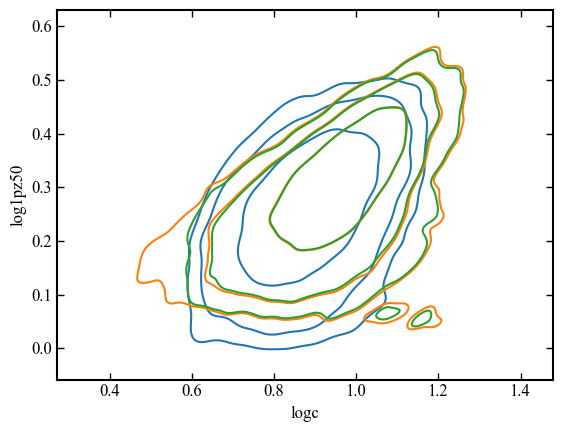

In [173]:
sns.kdeplot(x=art_500["logc"], y=art_500["log1pz50"], levels=levelz)
sns.kdeplot(x=bolnorm.df["logc"], y=bolnorm.df["log1pz50"], levels=levelz)
sns.kdeplot(x=bolnorm_cut.df["logc"], y=bolnorm_cut.df["log1pz50"], levels=levelz)

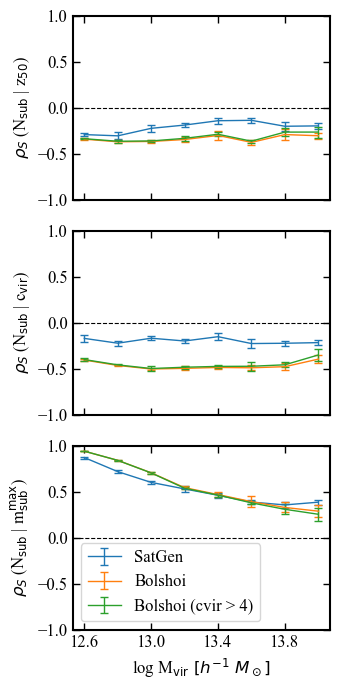

In [172]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [art_500norm, bolnorm, bolnorm_cut]
colors = ["C0", "C1", "C2"]
labelz = ["SatGen", "Bolshoi", "Bolshoi (cvir > 4)"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], label=labelz[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend()

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

In [67]:
def set_correlation(x, y, target_r):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_mean, x_std = x.mean(), x.std()
    y_mean, y_std = y.mean(), y.std()

    xz = (x - x_mean) / x_std
    yz = (y - y_mean) / y_std

    r1 = np.corrcoef(xz, yz)[0, 1]

    # residual of y orthogonal to x, then re-standardize
    e = yz - r1 * xz
    e = e / e.std()

    yz_new = target_r * xz + np.sqrt(1 - target_r**2) * e

    # rescale back to y's original mean/std
    y_new = yz_new * y_std + y_mean
    return y_new

In [123]:
def measure_acrossMvir(df):

    logMvir_bincenters = np.linspace(12.6, 14.0, 8)
    logMvir_binsize = 0.1

    rho_zc = []
    rho_zc_new = []

    rho_nc = []
    rho_nc_new = []

    rho_fc = []
    rho_fc_new = []

    new_logcs = []

    for center in logMvir_bincenters:
        selection = df[(df["logMvir"] > center-logMvir_binsize) & (df["logMvir"] <= center+logMvir_binsize)]
        bolselec = boltab[(boltab["logMvir"] > center-logMvir_binsize) & (boltab["logMvir"] <= center+logMvir_binsize)]
        
        rho_zc.append(jsm_stats.correlation(selection["log1pz50"], selection["logc"]))
        rho_nc.append(jsm_stats.correlation(selection["logNsub"], selection["logc"]))
        rho_fc.append(jsm_stats.correlation(selection["logfsub"], selection["logc"]))

        new_logc = set_correlation(selection["log1pz50"], selection["logc"], jsm_stats.correlation(bolselec["log1pz50"], bolselec["logc"]))

        rho_zc_new.append(jsm_stats.correlation(selection["log1pz50"], new_logc))
        rho_nc_new.append(jsm_stats.correlation(selection["logNsub"], new_logc))
        rho_fc_new.append(jsm_stats.correlation(selection["logfsub"], new_logc))

        new_logcs.append(new_logc)

    rho_array = np.array([[rho_zc, rho_zc_new], [rho_nc, rho_nc_new], [rho_fc, rho_fc_new]])

    return rho_array, new_logcs

<Axes: xlabel='log1pz50', ylabel='logc'>

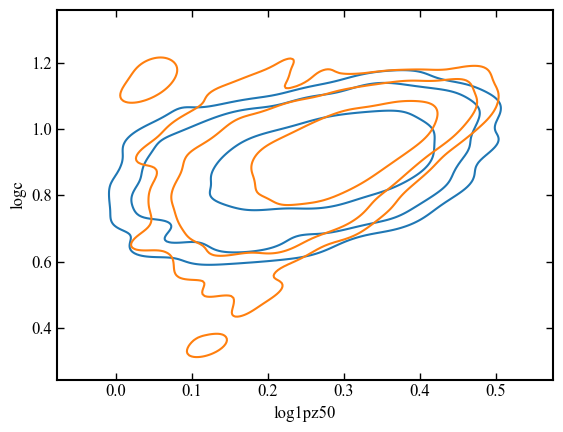

In [124]:
sns.kdeplot(x=selection_art["log1pz50"], y=selection_art["logc"], levels=levelz)
sns.kdeplot(x=selection_bol["log1pz50"], y=selection_bol["logc"], levels=levelz)

In [ ]:
test, logcs = measure_acrossMvir(art_500)
logMvir_bincenters = np.linspace(12.6, 14.0, 8)

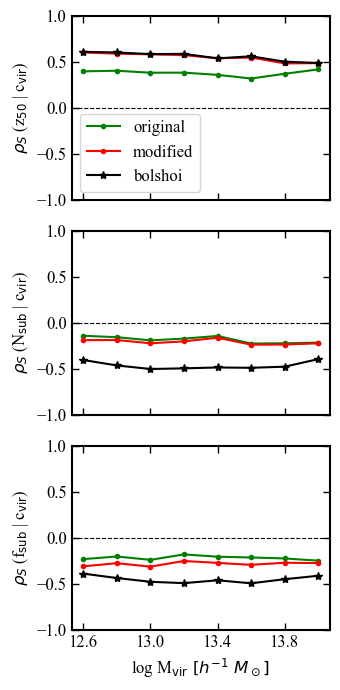

In [133]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

for i,vals in enumerate(test):

    axes[i].plot(logMvir_bincenters, vals[0], color="green", marker=".", label="original")
    axes[i].plot(logMvir_bincenters, vals[1], color="red", marker=".", label="modified")


axes[0].plot(logMvir_bincenters, bolnorm.rhocz_mat, marker="*", color="k", label="bolshoi")
axes[1].plot(logMvir_bincenters, bolnorm.rho_mat[1], marker="*", color="k", label="bolshoi")
axes[2].plot(logMvir_bincenters, bolnorm.rhofsub_mat[1], marker="*", color="k", label="bolshoi")


axes[0].legend()
axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")

axes[0].set_ylabel("$\\rho_S$ (z$_{50}$ | c$_{\\rm vir}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")



axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])

plt.tight_layout()
# plt.savefig("../../figures/DF_rho.pdf", bbox_inches="tight")
plt.show()

In [183]:
art_500_cut = art_500[art_500["log1pz50"] > 0.1]
art_500norm_cut = jsm_simload.NormalizeData(art_500_cut, dataset_title="satgen_cut", binsize=0.1)

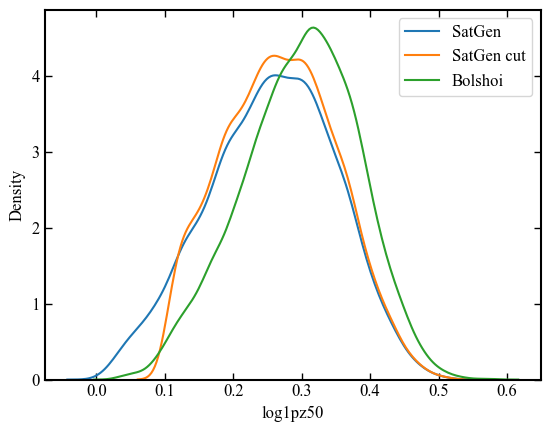

In [184]:
sns.kdeplot(art_500["log1pz50"], label="SatGen")
sns.kdeplot(art_500_cut["log1pz50"], label="SatGen cut")
sns.kdeplot(boltab["log1pz50"], label="Bolshoi")
plt.legend()

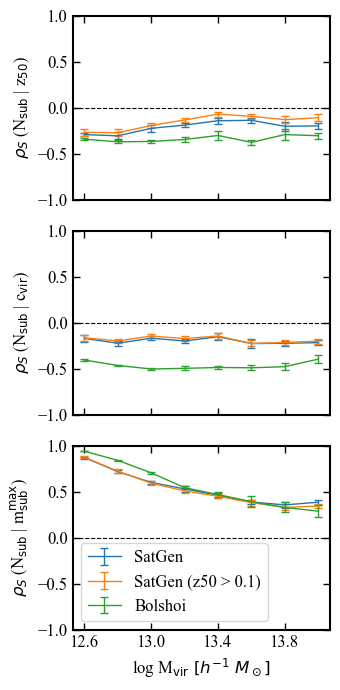

In [185]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [art_500norm, art_500norm_cut, bolnorm]
colors = ["C0", "C1", "C2"]
labelz = ["SatGen", "SatGen (z50 > 0.1)", "Bolshoi"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], label=labelz[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend()

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

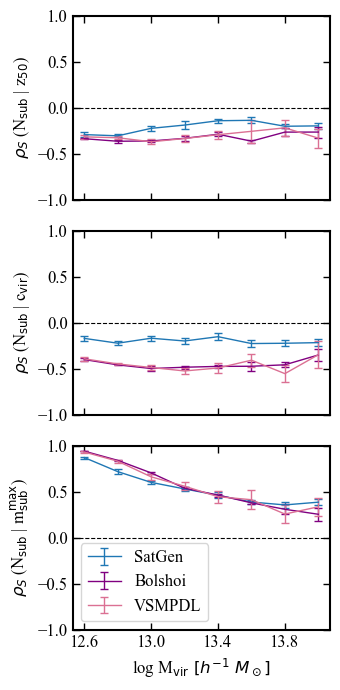

In [196]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [art_500norm, bolnorm_cut, smdplnorm_cut]
colors = ["C0", "purple", "palevioletred"]
labelz = ["SatGen", "Bolshoi", "VSMPDL"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], label=labelz[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(loc=3)

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

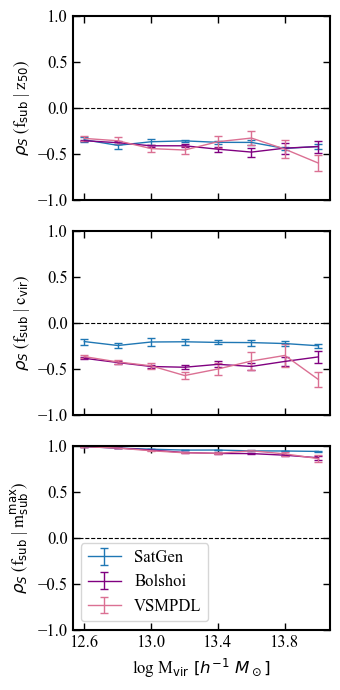

In [197]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [art_500norm, bolnorm_cut, smdplnorm_cut]
colors = ["C0", "purple", "palevioletred"]
labelz = ["SatGen", "Bolshoi", "VSMPDL"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rhofsub_mat[i], yerr=dataset.rho_errfsub_mat[i], color=colors[j], label=labelz[j], capsize=3, lw=1)

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(loc=3)

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()